In [2]:
from langgraph.graph import StateGraph,START,END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict
import time

In [3]:
#define state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str
    

In [ ]:
#define steps
def step1(state:CrashState)->CrashState:
    print("Step 1 executed")
    return {"step1":"done","input":state["input"]}
def step2(state:CrashState)->CrashState:
    print("Step 2 hanging...now manually interrupt from the notebook toolbar (stop button) to simulate a crash")
    time.sleep(30)
    return {"step2":"done"}
def step3(state:CrashState)->CrashState:
    print("Step 3 executed")
    return {"done":True}

In [6]:
#3.Build Graph
builder=StateGraph(CrashState)
builder.add_node("step1",step1)
builder.add_node("step2",step2)
builder.add_node("step3",step3)
builder.add_edge(START,"step1")
builder.add_edge("step1","step2")
builder.add_edge("step2","step3")
builder.add_edge("step3",END)
checkpointer=InMemorySaver()
graph=builder.compile(checkpointer=checkpointer)

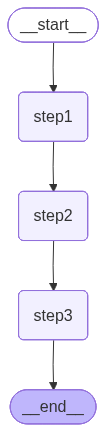

In [7]:
graph

In [8]:
try:
    print("Invoking graph...please manually interrupt the kernel during step 2 execution to simulate a crash")
    graph.invoke({"input":"start"},config={"configurable":{"thread_id":"crash_test-1"}})
except KeyboardInterrupt:
    print("Kernel interrupted, simulating crash...")

Invoking graph...please manually interrupt the kernel during step 2 execution to simulate a crash
Step 1 executed
Step 2 hanging...now manually interrupt from the notebook toolbar (stop button) to simulate a crash
Kernel interrupted, simulating crash...


In [9]:
graph.get_state(config={"configurable":{"thread_id":"crash_test-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step2',), config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447ee-b483-6928-8001-5835853940f4'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-04-30T10:25:32.914300+00:00', parent_config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447ee-b482-6935-8000-7e4fe127517a'}}, tasks=(PregelTask(id='213b9399-d9b6-c27c-e24c-39f6fda28596', name='step2', path=('__pregel_pull', 'step2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [10]:
#re run the graph to see if it resumes from the last checkpoint
final_state=graph.invoke(None,config={"configurable":{"thread_id":"crash_test-1"}})
print("Final state after resuming from checkpoint:",final_state)

Step 2 hanging...now manually interrupt from the notebook toolbar (stop button) to simulate a crash
Step 3 executed
Final state after resuming from checkpoint: {'input': 'start', 'step1': 'done', 'step2': 'done'}


In [11]:
graph.get_state(config={"configurable":{"thread_id":"crash_test-1"}})

StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447fa-b053-6de1-8003-9171cb38a0c2'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-30T10:30:54.597848+00:00', parent_config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447fa-b04e-67a4-8002-e4c759e4a156'}}, tasks=(), interrupts=())

In [13]:
list(graph.get_state_history(config={"configurable":{"thread_id":"crash_test-1"}}))

[StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=(), config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447fa-b053-6de1-8003-9171cb38a0c2'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-04-30T10:30:54.597848+00:00', parent_config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447fa-b04e-67a4-8002-e4c759e4a156'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'start', 'step1': 'done', 'step2': 'done'}, next=('step3',), config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447fa-b04e-67a4-8002-e4c759e4a156'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-04-30T10:30:54.595632+00:00', parent_config={'configurable': {'thread_id': 'crash_test-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1447ee-b483-6928-8001-5835853940f4'}}, tasks=(PregelTask(id='7748bf3b-47ba-1b5e-c

Timetravel